<a href="https://colab.research.google.com/github/Morales-Andres/Detectando-nuevos-planetas/blob/main/detectando_a_neptuno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalamos e importamos librerías necesarias
!pip install rebound
!pip install emcee
!pip install corner
!pip install astroquery
!pip install imageio
import os
import imageio
import rebound
import emcee
import corner
import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from astropy.constants import G
from astropy import units as u
from IPython.display import Image, display
from astroquery.jplhorizons import Horizons

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 785.9/785.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.8/994.8 kB 42.7 MB/s eta 0:00:00


In [ ]:
# Construimos el modelo

# Creamos la función para configurar la simulación según nuestro nuevo planeta
def setup_sim(params):
    # Desempaquetamos parámetros
    m, r, phi, theta, vr, vphi, vtheta = params

    # Creamos la simulación
    sim = rebound.Simulation()

    # Establecemos las unidades a utilizar
    sim.units = ['msun', 'AU', 'd']

    # Configuramos paso de tiempo
    sim.dt = 30

    # Fijamos el integrador
    sim.integrator = 'whfast'

    # Agregamos cuerpos a la simulación
    sim.add(m = m_sun, x = x_sun, y = y_sun, z = z_sun, vx = vx_sun, vy = vy_sun, vz = vz_sun) # Sol
    sim.add(m = m_mercury, x = x_mercury, y = y_mercury, z = z_mercury, vx = vx_mercury, vy = vy_mercury, vz = vz_mercury) # Mercurio
    sim.add(m = m_venus, x = x_venus, y = y_venus, z = z_venus, vx = vx_venus, vy = vy_venus, vz = vz_venus) # Venus
    sim.add(m = m_earth, x = x_earth, y = y_earth, z = z_earth, vx = vx_earth, vy = vy_earth, vz = vz_earth) # Tierra
    sim.add(m = m_mars, x = x_mars, y = y_mars, z = z_mars, vx = vx_mars, vy = vy_mars, vz = vz_mars) # Marte
    sim.add(m = m_jupiter, x = x_jupiter, y = y_jupiter, z = z_jupiter, vx = vx_jupiter, vy = vy_jupiter, vz = vz_jupiter) # Júpiter
    sim.add(m = m_saturn, x = x_saturn, y = y_saturn, z = z_saturn, vx = vx_saturn, vy = vy_saturn, vz = vz_saturn) # Saturno
    sim.add(m = m_uranus, x = x_uranus, y = y_uranus, z = z_uranus, vx = vx_uranus, vy = vy_uranus, vz = vz_uranus) # Urano

    # Proyectamos los datos a coordenadas cartesianas
    x = r * np.cos(phi) * np.sin(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(theta)
    vx = vr * np.cos(phi) * np.sin(theta) + vtheta * np.cos(phi) * np.cos(theta) - vphi * np.sin(phi)
    vy = vr * np.sin(phi) * np.sin(theta) + vtheta * np.sin(phi) * np.cos(theta) + vphi * np.cos(phi)
    vz = vr * np.cos(theta) - vtheta * np.sin(theta)

    # Añadimos el nuevo planeta a la simulación
    sim.add(m = m, x = x, y = y, z = z, vx = vx, vy = vy, vz = vz)

    # Movemos la simulación al centro
    sim.move_to_com()

    return sim

In [ ]:
# Creamos una función que nos permita calcular la velocidad radial en nuestro modelo
def vrad(planeta):
    # Creamos vectores de distancia y velocidad
    r = np.array([planeta.x, planeta.y, planeta.z])
    v = np.array([planeta.vx, planeta.vy, planeta.vz])

    # Calculamos la norma del vector d
    r_norm = np.linalg.norm(r)

    # Calculamos la velocidad radial
    vrad = np.dot(r, v) / r_norm

    return vrad

In [ ]:
# Obtenemos información de los planetas del sistema solar

# Creamos la simulación
simdata = rebound.Simulation()

# Establecemos las unidades a utilizar
simdata.units = ['msun', 'AU', 'd']

# Añadimos la estrella y los planetas a la simulación
simdata.add("Sun", date = "1740-01-01 00:00") # Sol
simdata.add("Mercury", date = "1740-01-01 00:00") # Mercurio
simdata.add("Venus", date = "1740-01-01 00:00") # Venus
simdata.add("Earth", date = "1740-01-01 00:00") # Tierra
simdata.add("Mars", date = "1740-01-01 00:00") # Marte
simdata.add("Jupiter", date = "1740-01-01 00:00") # Júpiter
simdata.add("Saturn", date = "1740-01-01 00:00") # Saturno
simdata.add("Uranus", date = "1740-01-01 00:00") # Urano
simdata.add("Neptune", date = "1740-01-01 00:00") # Neptuno
simdata.move_to_com()

# Guardamos masa, posiciones y velocidades iniciales para el modelo

# Sol
m_sun = simdata.particles[0].m
x_sun = simdata.particles[0].x
y_sun = simdata.particles[0].y
z_sun = simdata.particles[0].z
vx_sun = simdata.particles[0].vx
vy_sun = simdata.particles[0].vy
vz_sun = simdata.particles[0].vz

# Mercurio
m_mercury = simdata.particles[1].m
x_mercury = simdata.particles[1].x
y_mercury = simdata.particles[1].y
z_mercury = simdata.particles[1].z
vx_mercury = simdata.particles[1].vx
vy_mercury = simdata.particles[1].vy
vz_mercury = simdata.particles[1].vz

# Venus
m_venus = simdata.particles[2].m
x_venus = simdata.particles[2].x
y_venus = simdata.particles[2].y
z_venus = simdata.particles[2].z
vx_venus = simdata.particles[2].vx
vy_venus = simdata.particles[2].vy
vz_venus = simdata.particles[2].vz

# Tierra
m_earth = simdata.particles[3].m
x_earth = simdata.particles[3].x
y_earth = simdata.particles[3].y
z_earth = simdata.particles[3].z
vx_earth = simdata.particles[3].vx
vy_earth = simdata.particles[3].vy
vz_earth = simdata.particles[3].vz

# Marte
m_mars = simdata.particles[4].m
x_mars = simdata.particles[4].x
y_mars = simdata.particles[4].y
z_mars = simdata.particles[4].z
vx_mars = simdata.particles[4].vx
vy_mars = simdata.particles[4].vy
vz_mars = simdata.particles[4].vz

# Júpiter
m_jupiter = simdata.particles[5].m
x_jupiter = simdata.particles[5].x
y_jupiter = simdata.particles[5].y
z_jupiter = simdata.particles[5].z
vx_jupiter = simdata.particles[5].vx
vy_jupiter = simdata.particles[5].vy
vz_jupiter = simdata.particles[5].vz

# Saturno
m_saturn = simdata.particles[6].m
x_saturn = simdata.particles[6].x
y_saturn = simdata.particles[6].y
z_saturn = simdata.particles[6].z
vx_saturn = simdata.particles[6].vx
vy_saturn = simdata.particles[6].vy
vz_saturn = simdata.particles[6].vz

# Urano
m_uranus = simdata.particles[7].m
x_uranus = simdata.particles[7].x
y_uranus = simdata.particles[7].y
z_uranus = simdata.particles[7].z
vx_uranus = simdata.particles[7].vx
vy_uranus = simdata.particles[7].vy
vz_uranus = simdata.particles[7].vz

# Neptuno
m_neptune = simdata.particles[8].m
x_neptune = simdata.particles[8].x
y_neptune = simdata.particles[8].y
z_neptune = simdata.particles[8].z
vx_neptune = simdata.particles[8].vx
vy_neptune = simdata.particles[8].vy
vz_neptune = simdata.particles[8].vz

# Proyectamos las coordenadas de Neptuno a esféricas para comparar después
r_neptune = np.sqrt(x_neptune**2 + y_neptune**2 + z_neptune**2)
phi_neptune = np.arctan2(y_neptune, x_neptune)
theta_neptune = np.arccos(z_neptune/r_neptune)
vr_neptune = np.dot((x_neptune, y_neptune, z_neptune), (vx_neptune, vy_neptune, vz_neptune)) / r_neptune
vphi_neptune = np.linalg.norm(np.cross((x_neptune, y_neptune, z_neptune), (vx_neptune, vy_neptune, vz_neptune))) / r_neptune
vtheta_neptune = (x_neptune * vy_neptune - y_neptune * vx_neptune) / (x_neptune**2 + y_neptune**2)

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')


In [ ]:
# Buscamos crear datos de velocidad radial

# Definimos el objeto que buscamos (Uranus, ID 799) y el marco de tiempo
urano = Horizons(id = 799, location = '@sun', epochs = {'start':'1740-01-01', 'stop':'2242-01-01', 'step':'30d'})

# Buscamos datos de efemérides
uranovectors = urano.vectors()

# Guardamos datos de tiempo de medición y velocidad radial asociada
RV = uranovectors['range_rate']

In [ ]:
# Buscamos crear datos de velocidad radial

# Definimos el objeto que buscamos (Uranus, ID 799) y el marco de tiempo
urano = Horizons(id = 799, location = '@sun', epochs = {'start':'1740-01-01', 'stop':'2242-01-01', 'step':'30d'})

# Buscamos datos de efemérides
uranoephemerides = urano.ephemerides()

# Guardamos datos de tiempo de medición y velocidad radial asociada
r0 = np.mean(uranoephemerides['r'])

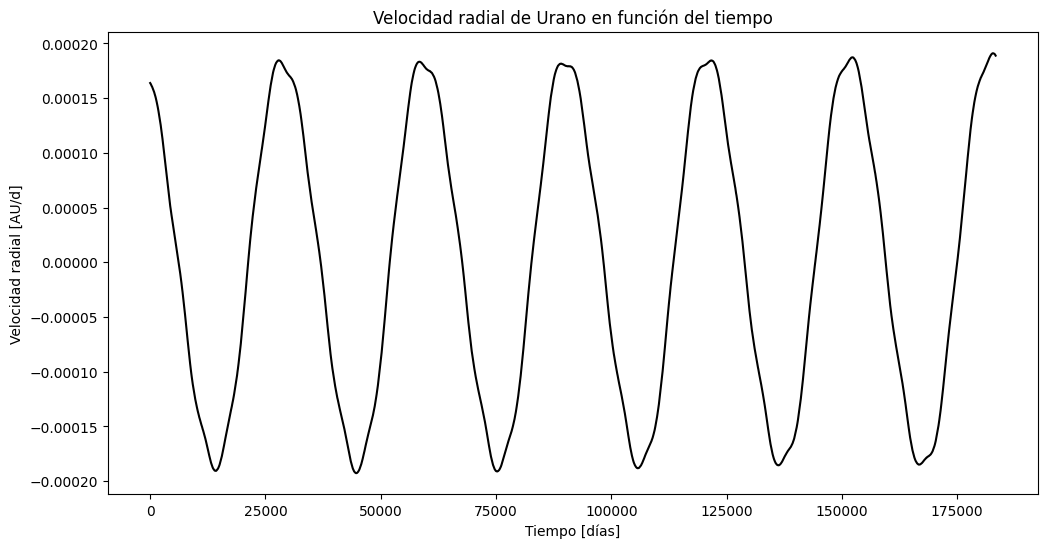

In [ ]:
# Graficamos la velocidad radial simulada para compararla posteriormente

# Definimos los tiempos de la simulación
times = np.arange(0, len(RV)*30, 30)

# Generamos la figura
rvplot = plt.figure(figsize = (12, 6))
plt.xlabel('Tiempo [días]')
plt.ylabel('Velocidad radial [AU/d]')
plt.title('Velocidad radial de Urano en función del tiempo')

# Graficamos la velocidad radial encontrada
plt.plot(times, RV, color = 'black')

# Mostramos la figura
plt.show()

In [ ]:
# Creamos una función de probabilidad logarítmica
def log_likelihood(params, RV, times):
    # Desempaquetamos los datos de nuestro planeta (masa, posición y velocidad)
    m, r, phi, theta, vr, vphi, vtheta = params

    # Aseguramos valores dentro de nuestros rangos
    if not all(min < p < max for p, (min, max) in zip(params, ranges)):
        return -np.inf

    # Simulamos con los parámetros
    sim = setup_sim(params)

    # Definimos la probabilidad inicial
    ll = 0.

    # Definimos un error para cada simulación
    sigma = np.mean(RV)

    # Creamos un array que almacenará los datos de velocidad radial
    RVsim = np.zeros(len(times))

    for i, t in enumerate(times):
        # Integramos la simulación por el tiempo
        sim.integrate(t)

        # Guardamos la velocidad de la simulación
        RVsim[i] = vrad(sim.particles[7])

        # Calculamos la diferencia entre la velocidades simuladas y medidas
        deltaRV = RVsim[i] - RV[i]

        # Añadimos a la probabilidad
        ll += -(deltaRV/sigma)**2

    return ll

In [ ]:
# Establecemos cantidad de walkers
ndim, nwalkers = 7, 30

# Función para crear condiciones iniciales random
def generate_random_ic(ranges):
    ic = [np.random.uniform(low, high) for low, high in ranges]
    return ic

# Definimos velocidad kepleriana asociada a urano
vk0 = (np.sqrt(G * m_sun * u.Msun /(r0 * u.AU))).to(u.AU / u.d).value

# Definimos un valor mínimo y máximo para cada parámetro
mmin = 1e-09
mmax = 1e-02
rmin = 1.2 * r0
rmax = 2.5 * r0
phimin = 0
phimax = 2 * np.pi
thetamin = np.pi * 1/4
thetamax = np.pi * 3/4
vrmin = - 0.05 * vk0
vrmax = + 0.05 * vk0
vphimin = (np.sqrt(G * m_sun * u.Msun / (rmax * u.AU))).to(u.AU / u.d).value - 0.05 * vk0
vphimax = (np.sqrt(G * m_sun * u.Msun / (rmin * u.AU))).to(u.AU / u.d).value + 0.05 * vk0
vthetamin = - 0.05 * vk0
vthetamax = + 0.05 * vk0

# Definimos los rangos para condiciones iniciales
ranges = [(mmin, mmax), (rmin, rmax), (phimin, phimax), (thetamin, thetamax), (vrmin, vrmax), (vphimin, vphimax), (vthetamin, vthetamax)]

# Condiciones iniciales para cada walker
ic = [generate_random_ic(ranges) for n in range(nwalkers)]

In [ ]:
# Definimos cuantas iteraciones tendrá nuestro modelo
iterations = 600

# Corremos nuestro MCMC
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, args = [RV, times])
state = sampler.run_mcmc(ic, iterations, progress = True)

100%|██████████| 600/600 [1:03:48<00:00,  6.38s/it]


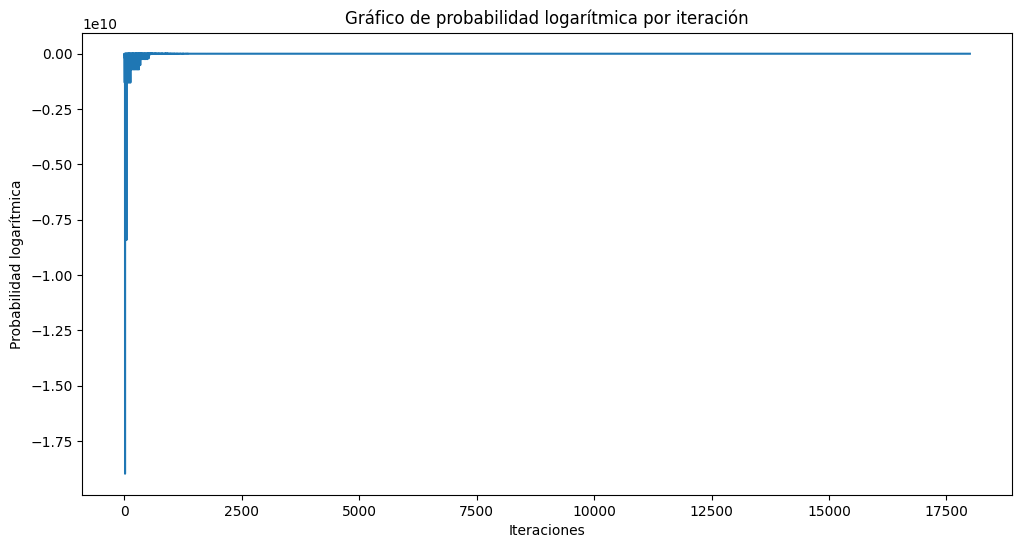

In [ ]:
# Revisamos la convergencia de nuestro MCMC ploteando la probabilidad logarítmica
logplot = plt.figure(figsize = (12, 6))
plt.xlabel('Iteraciones')
plt.ylabel('Probabilidad logarítmica')
plt.title('Gráfico de probabilidad logarítmica por iteración')
plt.plot(sampler.flatlnprobability)
plt.show()

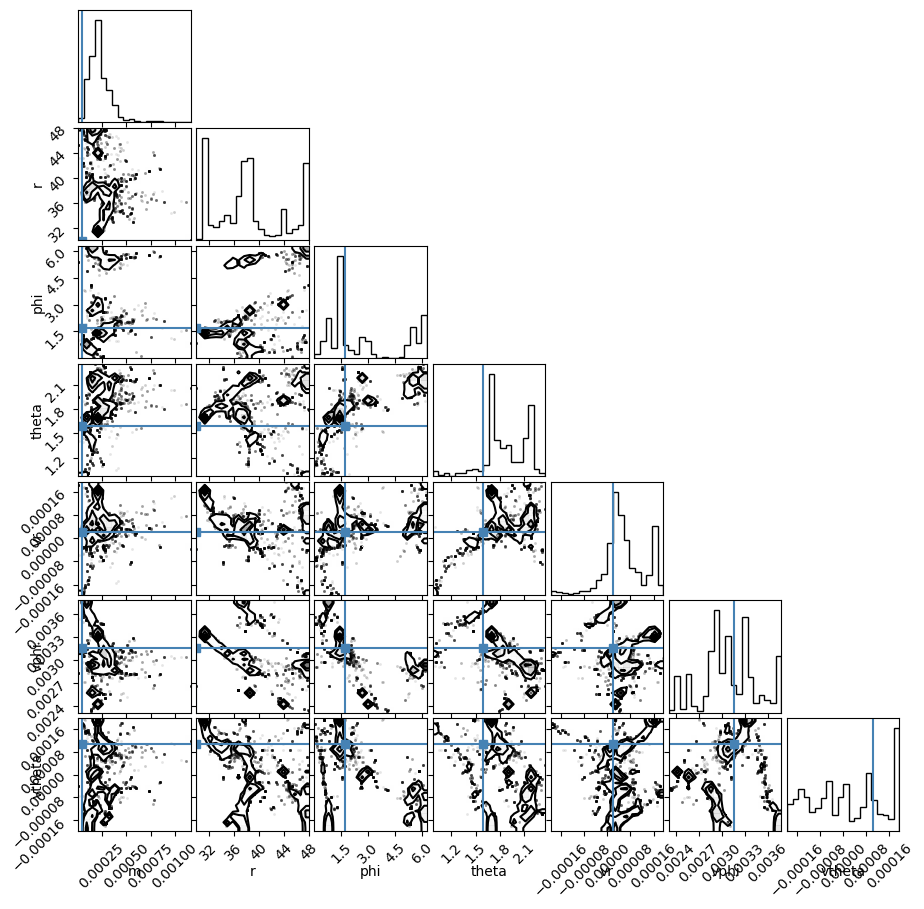

In [ ]:
# Nuevamente para revisar convergencia comparamos nuestros valores contra los reales usando corner
cornerplot = plt.figure(figsize = (9, 9))

corner.corner(sampler.flatchain[int(iterations * nwalkers * 1/10):],
              labels = ['m', 'r', 'phi', 'theta', 'vr', 'vphi', 'vtheta'],
              truths = [m_neptune, r_neptune, phi_neptune, theta_neptune, vr_neptune, vphi_neptune, vtheta_neptune],
              ranges = ranges,
              fig = cornerplot,
              quiet = True);

# Mostramos la figura
plt.show()

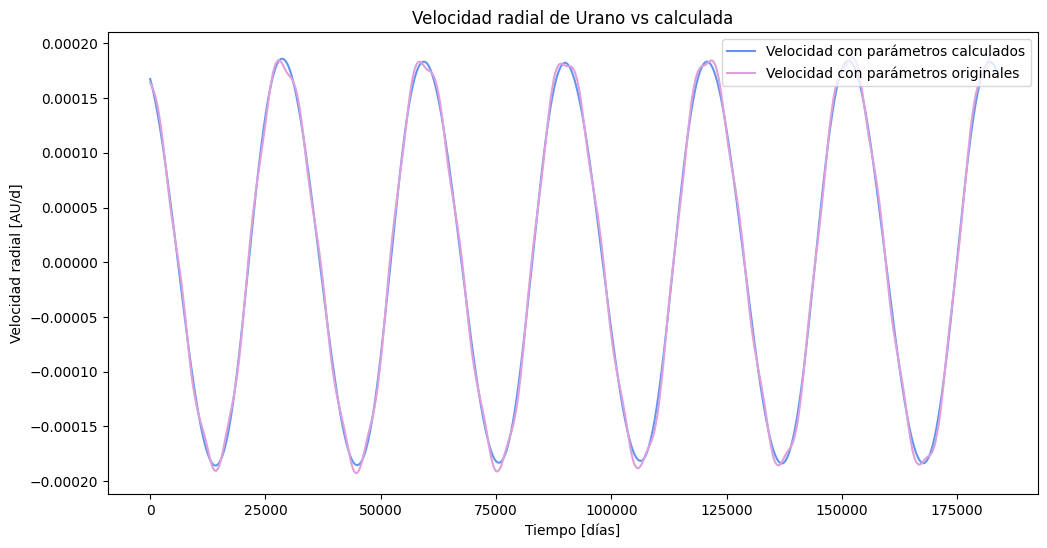

In [ ]:
# Recuperemos la mediana de los parámetros encontrados por el modelo y comparemos la velocidad radial con la simulada

# Todas las muestras
samples = sampler.chain

# Aplanar las muestras
flat_samples = sampler.get_chain(flat = True, discard = int(iterations * 1/10))

# Calcular la mediana de cada parámetro
median_params = np.median(flat_samples, axis = 0)

# Calcula desviación estándar de cada parámetro
std_params = np.std(flat_samples, axis = 0)

# Generamos la figura
rvsplot = plt.figure(figsize = (12, 6))

# Proyectamos los parámetros a coordenadas cartesianas
mplot, rplot, phiplot, thetaplot, vrplot, vphiplot, vthetaplot = median_params

# Creamos la simulación
simplot = setup_sim([mplot, rplot, phiplot, thetaplot, vrplot, vphiplot, vthetaplot])

# Creamos un array que almacenará los datos de velocidad radial
RVplot = np.zeros(len(times))

for i, t in enumerate(times):
        # Integramos la simulación por el tiempo
        simplot.integrate(t)

        # Guardamos la velocidad de la simulación
        RVplot[i] = vrad(simplot.particles[7])

# Graficamos la velocidad radial encontrada
plt.plot(times, RVplot, color = 'cornflowerblue')

# Graficamos la velocidad radial simulada
plt.plot(times, RV, color = 'plum')

# Añadimos títulos y leyenda
plt.title('Velocidad radial simulada vs. modelo')
plt.xlabel('Tiempo [días]')
plt.ylabel('Velocidad radial [AU/d]')
plt.title('Velocidad radial de Urano vs calculada')
plt.legend(['Velocidad con parámetros calculados', 'Velocidad con parámetros originales'], loc = 'upper right')

# Mostramos la figura
plt.show()

In [ ]:
print(f'Los parámetros encontrados son: m = {mplot}, r = {rplot}, phi = {phiplot}, theta = {thetaplot}, vr = {vrplot}, vphi = {vphiplot}, vtheta = {vthetaplot}')
print(f'Los parámetros reales son: m = {m_neptune}, r = {r_neptune}, phi = {phi_neptune}, theta = {theta_neptune}, vr = {vr_neptune}, vphi = {vphi_neptune}, vtheta = {vtheta_neptune}')
print(f'El error asociado a cada parámetro es: m = {std_params[0]}, r = {std_params[1]}, phi = {std_params[2]}, theta = {std_params[3]}, vr = {std_params[4]}, vphi = {std_params[5]}, vtheta = {std_params[6]}')

Los parámetros encontrados son: m = 0.00021255319864737726, r = 37.69764076459797, phi = 1.5842984778708704, theta = 1.8210333198667688, vr = 4.736307511070253e-05, vphi = 0.003074568387492346, vtheta = 5.215734260952752e-06
Los parámetros reales son: m = 5.151383772628957e-05, r = 29.907912149322065, phi = 1.7041168574079997, theta = 1.5881393525215177, vr = 2.0765903115585234e-05, vphi = 0.0031557093412957716, vtheta = 0.00010549562886762665
El error asociado a cada parámetro es: m = 0.00011514579494023255, r = 5.309986528983675, phi = 2.0687546337508707, theta = 0.2639757149727169, vr = 6.595151728715681e-05, vphi = 0.0003500313624543999, vtheta = 0.00012310231433577503


In [ ]:
# Gráfiquemos las órbitas dependiendo de los parametros

# Creamos la simulaciones con parámetros reales y calculados
simop1 = setup_sim([m_neptune, r_neptune, phi_neptune, theta_neptune, vr_neptune, vphi_neptune, vtheta_neptune])
simop2 = setup_sim([mplot, rplot, phiplot, thetaplot, vrplot, vphiplot, vthetaplot])

# Creamos la figura de la órbita inicial
op1 = rebound.OrbitPlot(simop1)
op2 = rebound.OrbitPlot(simop2)

# Creamos una lista para guardar las imágenes de la orbita
images1 = []
images2 = []

for i, t in enumerate(times):
    # Integramos la simulación por un tiempo
    simop1.integrate(t)
    simop2.integrate(t)

    # Actualizamos el gráfico
    op1.update()
    op2.update()

    # Creamos la figura de la órbita en el tiempo
    filename1 = f'orbit1_{i}.png'
    filename2 = f'orbit2_{i}.png'

    # Guardamos la figura
    op1.fig.savefig(filename1)
    op2.fig.savefig(filename2)

    # Añadimos la figura a la lista de imágenes
    images1.append(imageio.imread(filename1))
    images2.append(imageio.imread(filename2))

    # Eliminamos la imagen del directorio
    os.remove(filename1)
    os.remove(filename2)

# Creamos los gifs
imageio.mimsave('orbit1.gif', images1, fps = int(len(times) * 1/10))
imageio.mimsave('orbit2.gif', images2, fps = int(len(times) * 1/10))

# Nos aseguramos que no se muestre la órbita inicial
plt.close(op1.fig)
plt.close(op2.fig)

In [ ]:
# Mostramos las órbitas
display(Image(filename = 'orbit1.gif'))
display(Image(filename = 'orbit2.gif'))